<a href="https://colab.research.google.com/github/fatihonay/Neural-Variability-/blob/main/docs/source/Tutorials/CSD_Volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# All is One: The Curse of Volume Conduction in EEG

 The skull smears electrical activity and therefore a single neural source to be recorded by many distant electrodes. This phehomena is called as `volume conduction` which inflates the scalp electrophsilogical activity. Spatial filtering techniques can alleviate this problem. The most common way of dealing with volume conduction effect is to use `Surface Laplacian` spatial filtering. It basically transforms surface potential (Volt) into the current source density ( $V/m^2$ ). Conceptually, it allows to reveal local source currents beneath the surface of the scalp.In this tutorial, I will try to show how Surface Laplacian leads to sharper more localized activity topographical maps. Let's begin !

 Firstly,  I will impor a data   





In [ ]:
pip install mne


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the MNE Sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'

# 2. Read the raw data
raw = mne.io.read_raw_fif(raw_fname, preload=True)


In [10]:

# 3. Pick only EEG channels (CSD is specific to EEG)
raw.pick(['eeg', 'stim'])

# Check if the raw data already has positions
print(raw.get_montage())

# If this prints "None" or an empty object,
# you MUST set a standard montage before running CSD.
if raw.get_montage() is None:
    print("No positions found. Setting standard montage...")
    montage = mne.channels.make_standard_montage('standard_1005')
    raw.set_montage(montage)

print("Data imported and EEG channels selected successfully.")
print(raw.info)

<DigMontage | 78 extras (headshape), 4 HPIs, 3 fiducials, 59 channels>
Data imported and EEG channels selected successfully.
<Info | 14 non-empty values
 bads: []
 ch_names: STI 001, STI 002, STI 003, STI 004, STI 005, STI 006, STI 014, ...
 chs: 9 Stimulus, 59 EEG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 68
 projs: Average EEG reference: off
 sfreq: 150.2 Hz
>


We loaded the data successfully. This data includes a task where the participant was presented with auditory and visual stimuli.

To see the effect of CSD filtering clearly, we need to isolate specific brain responses. We will choose a single event type—Auditory stimulation to the left ear and extract the trials associated with it. This process cuts the continuous EEG signal into time-locked segments. Thus, we will able to to analyze the brain's reaction to that specific stimulus.

In [37]:
# 1. Find all events in the raw data
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)

# 2. Define the event we are interested in
event_id = {'Auditory/Left': 1}

# 3. Define the time window for our trials (epochs)
tmin, tmax = -0.2, 0.5

# 4. Create the trials
epochs = mne.Epochs(raw, events, event_id, tmin, tmax,
                    baseline=(None, 0), preload=True, verbose=False)

# 5. Compute the Evoked response (Average of all trials)
# Averaging removes random noise, making the CSD comparison much clearer later
evoked = epochs.average()

print(f"Number of trials extracted: {len(epochs)}")
print("Evoked response computed successfully.")

Number of trials extracted: 72
Evoked response computed successfully.


It is time to plot topographical maps.  We will plot default EEG map and spatial filtered EEG map together. For this purpose, we will use `compute_current_source_density` function from MNE library.

Fitted sphere radius:         91.2 mm
Origin head coordinates:      -4.2 16.4 51.8 mm
Origin device coordinates:    1.5 18.2 -10.1 mm


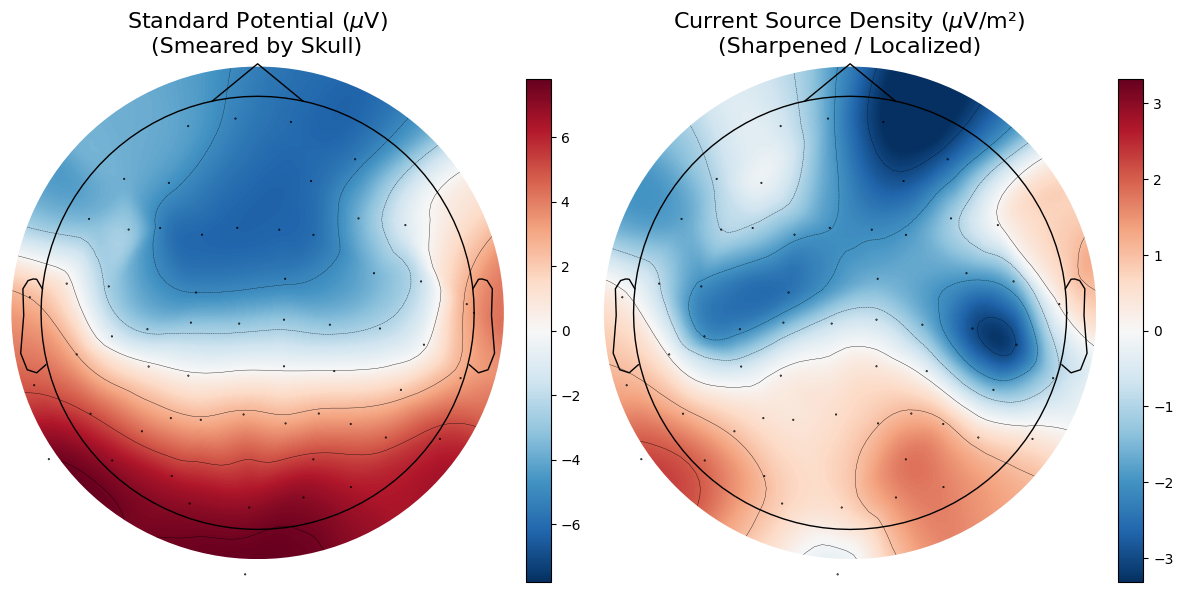

In [38]:
import matplotlib.pyplot as plt

# 1. Setup the figure with 2 subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=100)

# --- Plot 1: Standard Voltage ---
im_v = evoked.plot_topomap(times = 0.1, ch_type='eeg',
                           axes=axes[0], colorbar=False, show=False)

# Add title using 'rf' string to fix the \mu warning
axes[0].set_title(rf'Standard Potential ($\mu$V)' + '\n(Smeared by Skull)', fontsize=16)

# Manually add the colorbar for the first plot
fig.colorbar(axes[0].images[0], ax=axes[0], fraction=0.046, pad=0.04)

evoked_csd = mne.preprocessing.compute_current_source_density(evoked)


# --- Plot 2: CSD / Surface Laplacian ---
im_csd = evoked_csd.plot_topomap(times=0.1, ch_type='csd',
                                 axes=axes[1], colorbar=False, show=False)

axes[1].set_title(rf'Current Source Density ($\mu$V/m²)' + '\n(Sharpened / Localized)', fontsize=16)

# Manually add the colorbar for the second plot
fig.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046, pad=0.04)

# Final layout adjustments
plt.tight_layout()
plt.show()

As you can see, the topo maps clearly show the differences between two conditions. On the left side, surface potentials are not able to represent local sources. We can only see one strong soucre which supress others due to the volume conduction. On the other hand, the CSD map shows sharper topo map chracterizing distribute source of neurophsilogical acitivty.


Let's do same procedure for the another stimuli. The prior one was auditory stimulus. Now, let's try to observe visual stimulus as well.

In [56]:
# 1. Define the new event (Visual Left)
event_id_vis = {'Visual/Right': 4}

# 2. Create Epochs for Visual trials
epochs_vis = mne.Epochs(raw, events, event_id_vis, tmin, tmax,
                    baseline=(None, 0), preload=True, verbose=False)

# 5. Compute the Evoked response (Average of all trials)
evoked_vis = epochs_vis.average()

# 4. Compute CSD transform
evoked_vis_csd = mne.preprocessing.compute_current_source_density(evoked_vis)

print(f"Extracted {len(epochs_vis)} Visual trials.")
print("Visual CSD transformation complete.")

Fitted sphere radius:         91.2 mm
Origin head coordinates:      -4.2 16.4 51.8 mm
Origin device coordinates:    1.5 18.2 -10.1 mm
Extracted 70 Visual trials.
Visual CSD transformation complete.


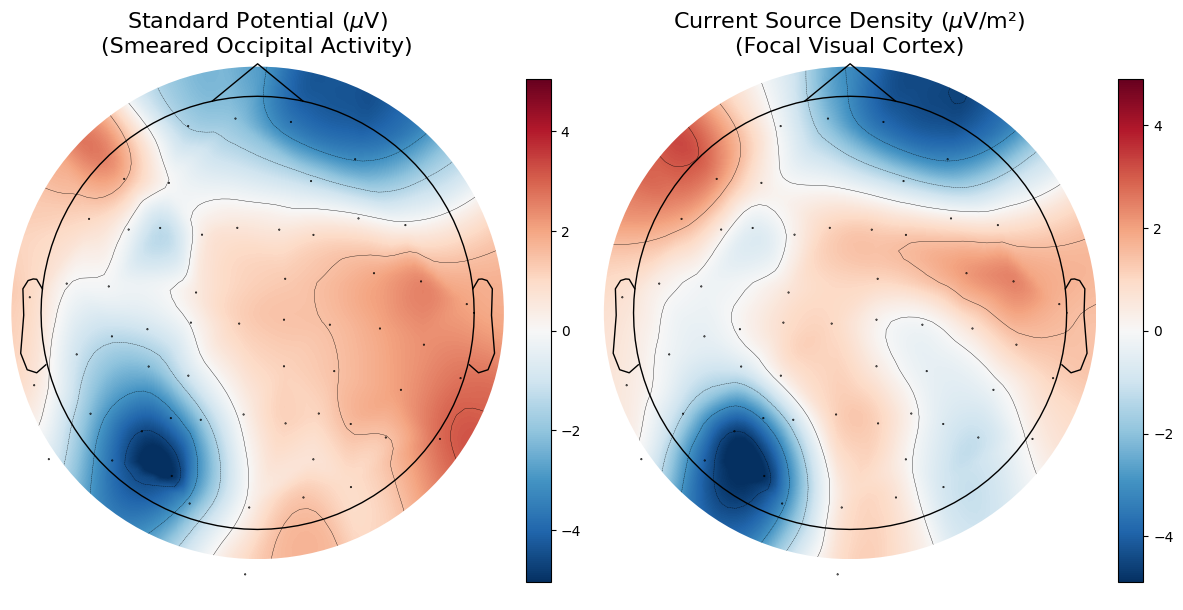

In [57]:
import matplotlib.pyplot as plt

# Setup the figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=100)

# --- Plot 1: Standard Voltage (Visual) ---
im_v = evoked_vis.plot_topomap(times= 0.15, ch_type='eeg',
                               axes=axes[0], colorbar=False, show=False)
axes[0].set_title(rf'Standard Potential ($\mu$V)' + '\n(Smeared Occipital Activity)', fontsize=16)
fig.colorbar(axes[0].images[0], ax=axes[0], fraction=0.046, pad=0.04)

# --- Plot 2: CSD (Visual) ---
im_csd = evoked_vis_csd.plot_topomap(times=0.15, ch_type='csd',
                                     axes=axes[1], colorbar=False, show=False)
axes[1].set_title(rf'Current Source Density ($\mu$V/m²)' + '\n(Focal Visual Cortex)', fontsize=16)
fig.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

This one was more ambigous in term of difference in spatial patterns.  However, we can still minor improvement in the right hemisphere.